In [15]:
import numpy as np
import matplotlib.pyplot as plt
import inspect
import tqdm as tqdm
import math

In [16]:
kappa_schloegl = np.array((6,1,230,1000))

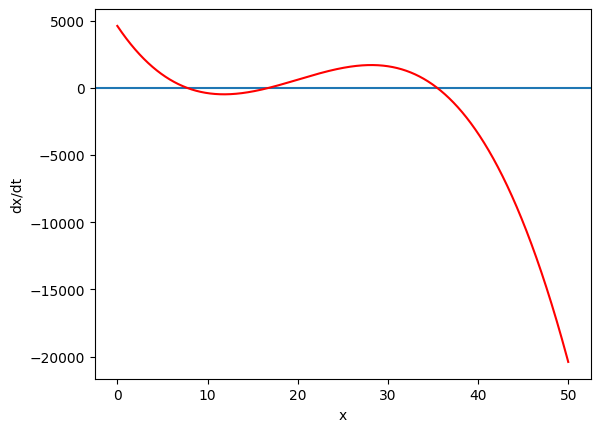

In [17]:
def dx_versus_dt(kappa,a,b,x):
    y = kappa[0]*a*x**2-kappa[1]*x**3-kappa[3]*x+kappa[2]*b
    return y

x_axis = np.linspace(0,50,100000)
y_axis = dx_versus_dt(kappa_schloegl,10,20,x_axis)
plt.axhline(y=0.0)
plt.plot(x_axis, y_axis, color='red')
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.show()

In [18]:
a = 10.
b = 20.
vol = 40.
y_axis_abs = abs(y_axis)
idx = np.where(y_axis_abs<0.1)[0]
print(x_axis[idx])
print(x_axis[idx]*vol)

[ 7.70307703  7.70357704 16.84216842 16.84266843 16.84316843 35.45385454]
[ 308.12308123  308.14308143  673.68673687  673.70673707  673.72673727
 1418.15418154]


In [19]:
"""
def generate_shoegl_Q(x_state:np.array, kappa:np.array, a,b,vol):
    print(f"vol equals to {vol}.")
    rank = x_state.size
    Q = np.zeros((rank, rank))

    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol
    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)
  
    Q_mu, Q_lamb = mu_n(x_state), lamb_n(x_state)    
    # Q_mu = np.roll(mu_n(x_state),-1)
    
    Q[np.eye(rank, k=1, dtype='bool')] = Q_mu[1:]
    Q[np.eye(rank, k=-1, dtype='bool')] = Q_lamb[:-1]
    Q_lamb[-1] = 0. # otherwise the Q does not satisfy column-wise or row-wise sum up to 1.
    np.fill_diagonal(Q, -(Q_lamb+Q_mu))

    return Q
"""

'\ndef generate_shoegl_Q(x_state:np.array, kappa:np.array, a,b,vol):\n    print(f"vol equals to {vol}.")\n    rank = x_state.size\n    Q = np.zeros((rank, rank))\n\n    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol\n    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)\n\n    Q_mu, Q_lamb = mu_n(x_state), lamb_n(x_state)    \n    # Q_mu = np.roll(mu_n(x_state),-1)\n\n    Q[np.eye(rank, k=1, dtype=\'bool\')] = Q_mu[1:]\n    Q[np.eye(rank, k=-1, dtype=\'bool\')] = Q_lamb[:-1]\n    Q_lamb[-1] = 0. # otherwise the Q does not satisfy column-wise or row-wise sum up to 1.\n    np.fill_diagonal(Q, -(Q_lamb+Q_mu))\n\n    return Q\n'

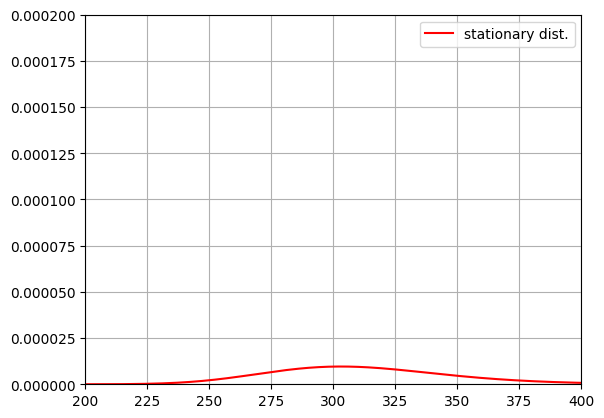

In [24]:
def get_analytical_dist(p_max, kappa, a, b, vol):
    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol
    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)
    
    # We will compute log(P(n)) to avoid numerical underflow/overflow
    log_p = np.zeros(p_max)
    log_p[0] = 0.0 # Arbitrary unnormalized start
    
    for n in range(1, p_max):
        log_p[n] = log_p[n-1] + np.log(lamb_n(n-1)) - np.log(mu_n(n))
        
    # Subtract max to prevent overflow when doing np.exp()
    log_p -= np.max(log_p)
    
    # Convert back to standard probability and normalize
    p_dist = np.exp(log_p)
    p_dist /= np.sum(p_dist) 
    
    return p_dist

# Now just run it!
p_max = 2500
p = np.arange(p_max)
stat_dist = get_analytical_dist(p_max, kappa_schloegl, a, b, vol=40.)
plt.xlim(200,400)
plt.ylim(0,0.0002)
plt.plot(p, stat_dist, color='r', label='stationary dist.')
plt.grid()
plt.legend()
plt.show()